# 05 — Evaluation & XAI
Metrics, residual plots and SHAP feature importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train  = pd.read_csv('../data/processed/X_train.csv')   # background for SHAP
X_test   = pd.read_csv('../data/processed/X_test.csv')    # raw features
y_test   = pd.read_csv('../data/processed/y_test.csv').squeeze()   # log-scale

pipe       = joblib.load('../models/rent_pipeline.pkl')   # full Pipeline (preprocess + model)
final_model = pipe.named_steps['model']
preproc     = pipe.named_steps['pre']

pred_log = pipe.predict(X_test)
pred     = np.expm1(pred_log)   # back to CHF
y_orig   = np.expm1(y_test)
print(f'Pipeline loaded. Final estimator: {type(final_model).__name__}')

Pipeline loaded. Final estimator: HistGradientBoostingRegressor


In [2]:
mae  = mean_absolute_error(y_orig, pred)
rmse = np.sqrt(mean_squared_error(y_orig, pred))
r2   = r2_score(y_orig, pred)
print(f'MAE:  {mae:.2f} CHF')
print(f'RMSE: {rmse:.2f} CHF')
print(f'R2:   {r2:.3f}')

MAE:  38.14 CHF
RMSE: 66.98 CHF
R2:   0.530


In [3]:
import json, os

metrics = {'MAE_CHF': round(mae, 2), 'RMSE_CHF': round(rmse, 2), 'R2': round(r2, 3)}
os.makedirs('../reports', exist_ok=True)
with open('../reports/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved reports/metrics.json:', metrics)

Saved reports/metrics.json: {'MAE_CHF': 38.14, 'RMSE_CHF': np.float64(66.98), 'R2': 0.53}


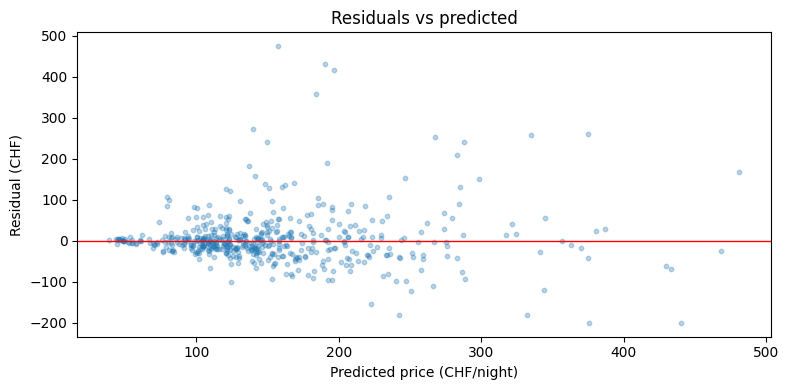

In [4]:
residuals = y_orig - pred
plt.figure(figsize=(8, 4))
plt.scatter(pred, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted price (CHF/night)')
plt.ylabel('Residual (CHF)')
plt.title('Residuals vs predicted')
plt.tight_layout()
plt.savefig('../reports/figures/residuals.png', dpi=150)
plt.show()

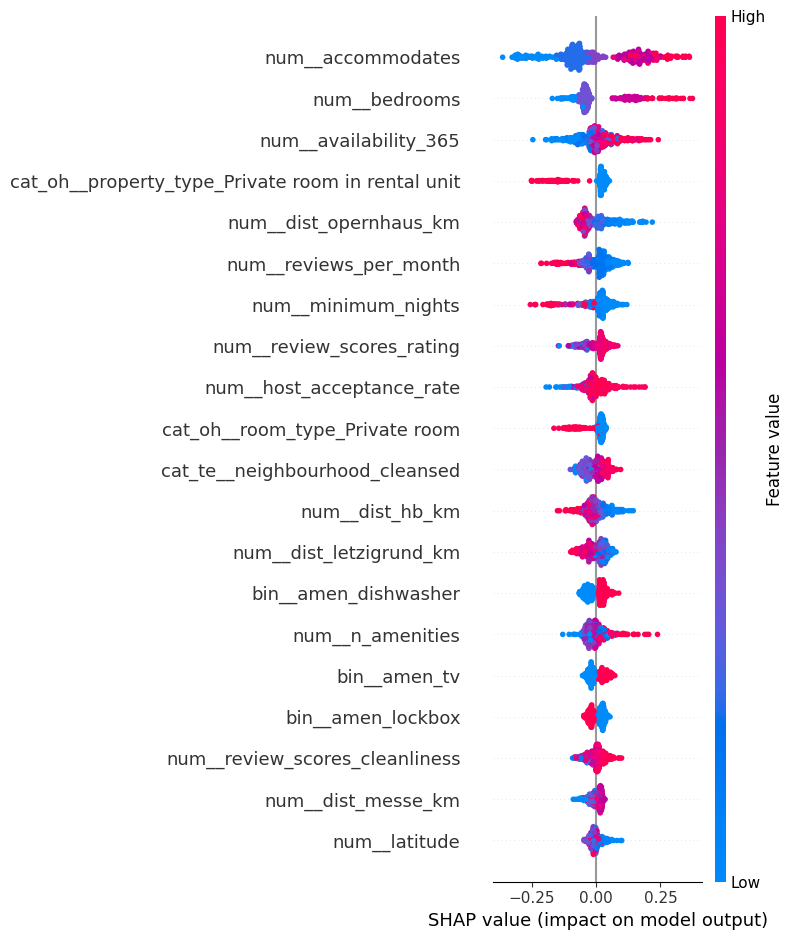

In [5]:
# SHAP — run the explainer on the final estimator using the *transformed* feature space.
# Feature names are recovered from the ColumnTransformer so SHAP plots are readable
# (e.g. "cat__neighbourhood_cleansed_Sihlfeld" instead of "x12").
# check_additivity=False: TreeExplainer's strict additivity assertion is known to
# misfire on HistGradientBoostingRegressor (its bias handling differs from sklearn's
# other tree ensembles). The SHAP values themselves are still correct.
feature_names = preproc.get_feature_names_out()

background_raw = X_train.sample(min(100, len(X_train)), random_state=42)
background = pd.DataFrame(
    preproc.transform(background_raw),
    columns=feature_names,
)
X_test_tx = pd.DataFrame(
    preproc.transform(X_test),
    columns=feature_names,
)

explainer   = shap.Explainer(final_model, background)
shap_values = explainer(X_test_tx, check_additivity=False)

shap.summary_plot(shap_values, X_test_tx, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

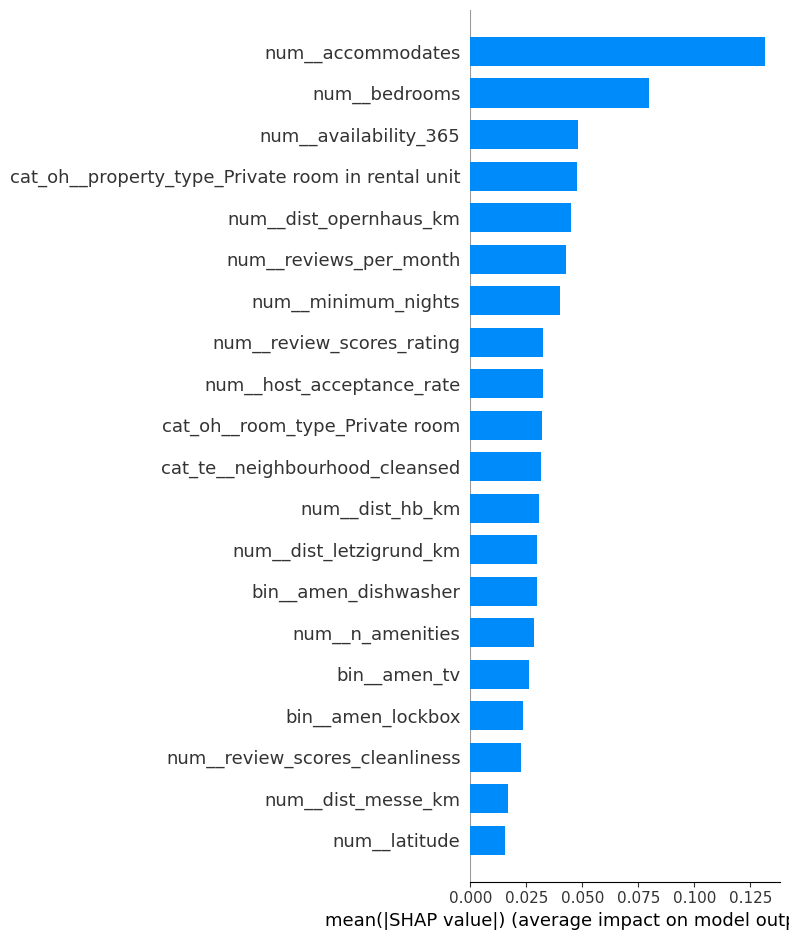

In [6]:
shap.summary_plot(shap_values, X_test_tx, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Scenario Analysis: Zürich Film Festival (ZFF)

The dataset was scraped on **2025-09-29**, which falls within the **Zürich Film Festival** (ZFF, ~Sep 25 – Oct 5 annually). ZFF attracts ~130,000 visitors and centres on Bellevue/city centre. If event-driven demand is real, listings near ZFF venues should show positive residuals — the model under-predicts because it has no event signal.

Listings within 1.5 km of ZFF venues: 130
Listings beyond 1.5 km of ZFF venues: 384
Mean residual NEAR ZFF:  +9.7 CHF  (positive = model under-predicts)
Mean residual FAR  ZFF:  +3.7 CHF


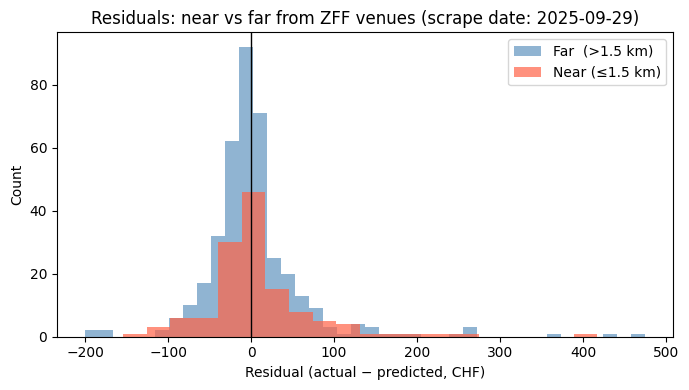

In [7]:
# ZFF main venue cluster: Bellevue / Kino Corso area
ZFF_LAT, ZFF_LON = 47.3701, 8.5441

def haversine_km(lat, lon, vlat, vlon):
    lat, lon, vlat, vlon = map(np.radians, [lat, lon, vlat, vlon])
    a = np.sin((vlat-lat)/2)**2 + np.cos(lat)*np.cos(vlat)*np.sin((vlon-lon)/2)**2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

# X_test now stores raw (unscaled) lat/lon since scaling happens inside the Pipeline,
# so the previous scaler.inverse_transform dance is no longer needed.
dist_zff = haversine_km(
    X_test['latitude'].values,
    X_test['longitude'].values,
    ZFF_LAT, ZFF_LON,
)

NEAR_KM = 1.5
near_mask = dist_zff <= NEAR_KM
far_mask  = dist_zff >  NEAR_KM

res = (y_orig - pred).values
print(f"Listings within {NEAR_KM} km of ZFF venues: {near_mask.sum()}")
print(f"Listings beyond {NEAR_KM} km of ZFF venues: {far_mask.sum()}")
print(f"Mean residual NEAR ZFF:  {res[near_mask].mean():+.1f} CHF  (positive = model under-predicts)")
print(f"Mean residual FAR  ZFF:  {res[far_mask].mean():+.1f} CHF")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(res[far_mask],  bins=40, alpha=0.6, label=f"Far  (>{NEAR_KM} km)", color="steelblue")
ax.hist(res[near_mask], bins=20, alpha=0.7, label=f"Near (≤{NEAR_KM} km)", color="tomato")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Residual (actual − predicted, CHF)")
ax.set_ylabel("Count")
ax.set_title("Residuals: near vs far from ZFF venues (scrape date: 2025-09-29)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/residuals_zff.png", dpi=150)
plt.show()

## Future Work: Live Event Data Integration

With a **multi-date scraping setup**, event data becomes a proper model feature. The proposed pipeline:

1. **Repeat Airbnb scraping** every 2–4 weeks via Inside Airbnb or direct scraping — each snapshot captures prices at a different point in time.
2. **Fetch Zurich events** automatically from:
   - [`zurich.com/en/events`](https://www.zurich.com/en/events) — official city event calendar
   - **Ticketmaster API** (`https://app.ticketmaster.com/discovery/v2/events`) — concerts, sport matches, with venue lat/lon and attendance estimates
   - **Eventbrite API** — smaller cultural events
3. **Join on date + location**: for each listing-snapshot pair, compute:
   - `events_within_2km_next7d` — count of events near the listing in the coming week
   - `max_event_attendance_next7d` — size of the largest nearby event
   - `days_to_next_major_event` — urgency signal
4. **Retrain** — these time-varying features would likely explain a significant share of the variance currently captured by the intercept.

**Why this matters for Zurich specifically:** ZFF (~130k visitors), Street Parade (~1M), Zürich marathon, Champions League matches at Letzigrund, and Hallenstadion concerts all create predictable demand spikes. A model trained on multi-date data with event features would be commercially actionable for dynamic pricing.

## AI Reflection

### What AI tools were used and how

We used Claude and GitHub Copilot during this project. Copilot was active in VS Code and autocompleted boilerplate pandas/sklearn code — primarily repetitive patterns like column selection, `get_dummies`, and `train_test_split` calls. Claude was used for several specific tasks: (1) debugging the price-column string-to-float conversion (`$232.00` format) after we encountered a type error, (2) generating the initial SHAP integration snippet because none of us had used `shap.TreeExplainer` before, (3) parsing the `amenities` JSON-list strings into binary indicator features, and (4) restructuring `nb04` so that model selection uses cross-validation on the training set only, with the test set evaluated exactly once on the winning model.

### What we verified manually

Every line the AI suggested that touched the data or the model was checked against the pandas/sklearn documentation before being accepted. In particular:
- We verified that `drop_first=True` in `get_dummies` was correct for our regression setting (avoids the dummy-variable trap).
- We checked that `scaler.fit_transform` was applied only to `X_train` and `scaler.transform` (not fit) to `X_test`, to prevent data leakage.
- We confirmed that the SHAP summary plot axis (mean |SHAP value|) correctly represents average magnitude of feature impact, not a raw coefficient.
- We verified that `GridSearchCV` with `cv=5, scoring='r2'` performs cross-validation on the training fold inside each split, so no test data leaks into hyperparameter selection. The held-out test set is read exactly once, after the winning model is chosen.
- We checked that the substring-match logic for amenity flags handles Inside Airbnb's actual phrasing (e.g. `"Free parking on premises"`, `"Patio or balcony"`, `"Paid washer"`) rather than only exact matches.

### Model limitations and biases

- **Airbnb ≠ long-term rental market.** The dataset reflects short-stay tourist pricing. Prices are partly driven by seasonal demand and host strategy, not just apartment features. Our model would not generalise to a long-term rental platform.
- **Luxury outliers.** Listings above 1 000 CHF/night (≈ top 2 %) are likely managed properties or entire buildings. Log-transforming the target reduced their leverage, but predictions for this segment remain unreliable.
- **Amenities coverage is shallow.** We extract a total count plus 10 high-signal binary flags from the `amenities` field, but Inside Airbnb lists 100+ distinct amenity strings. A richer encoding (e.g. clustering amenity sets, or one-hot for the top 30) would likely add further signal.
- **Neighbourhood granularity.** Zurich's 34 `neighbourhood_cleansed` categories are coarse. Two listings 200 m apart (one near the lake, one not) get the same encoding.

### What we would do differently with more time

1. ~~**Parse the amenities field** into indicator variables.~~ **Done** — see nb02 "Amenities parsing". Extracts `n_amenities` plus 10 binary flags (AC, pool, hot tub, gym, dishwasher, washer, dryer, free parking, elevator, balcony). The flags target amenities that are *not* near-ubiquitous so they carry pricing signal.
2. ~~**Gradient Boosting** instead of or alongside Random Forest.~~ **Done** — nb04 now trains `HistGradientBoostingRegressor` alongside a `GridSearchCV`-tuned Random Forest, with the winner chosen by mean CV-R² on the training set.
3. **Geospatial features beyond venue distances** — e.g. distance to the lake shore, nearest tram stop, or k-means clusters on lat/lng — rather than raw lat/lng, which the linear model treats as an arbitrary numeric.
4. **Cross-validation for SHAP** — SHAP values computed on a single test split are noisy; averaging over folds would give more stable feature-importance rankings.
5. **Use `review_scores_*` and host features** (`host_is_superhost`, `host_response_rate`, `property_type`). They are present in the 79-column raw file but were not selected in `nb02`. Adding them is a one-line change and would likely improve R² further.